# Eastern US Aerosol/Precursor Trend Analysis

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from pathlib import Path
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib import gridspec
import cartopy.feature as cfeature
from matplotlib.lines import Line2D
from scipy.stats import spearmanr, linregress

import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 9, 'figure.dpi': 120,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

# Per-pollutant start years
POLLUTANT_START = {
    'SO2':   1971,
    'PM2.5': 1999,
}

START_YEAR    = 2000
END_YEAR      = 2024
BASELINE_YRS  = (2000, 2004)
RECENT_YRS    = (2020, 2024)
MIN_LON       = -90.0
MIN_COMPLETE  = 75.0
MIN_YRS_TREND = 10     # Originally 15 but relaxed to 10 so that Maine stations would be included in PM2.5 sig

PROCESSED_DIR = Path('data/processed')
FIGURES_DIR   = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

In [2]:
raw = {}
for param in ['SO2', 'PM2.5', 'PM25_SO4']:
    matches = sorted(PROCESSED_DIR.glob(f'{param}_annual_*_eastern_us.csv'))
    if matches:
        fpath = matches[-1]
        raw[param] = pd.read_csv(fpath, low_memory=False)
        print(f'{param:10s}: {len(raw[param]):>8,} records  ({fpath.name})')
    else:
        print(f'{param:10s}: NOT FOUND')

if not raw:
    raise RuntimeError('No data loaded. Download first.')


SO2       :  143,670 records  (SO2_annual_1971_2024_eastern_us.csv)
PM2.5     :  207,055 records  (PM2.5_annual_1999_2024_eastern_us.csv)
PM25_SO4  :    4,456 records  (PM25_SO4_annual_1999_2024_eastern_us.csv)


In [3]:
STATE_NAME_TO_ABBR = {
    'Alabama': 'AL', 'Arkansas': 'AR', 'Connecticut': 'CT',
    'District Of Columbia': 'DC', 'Delaware': 'DE', 'Florida': 'FL',
    'Georgia': 'GA', 'Illinois': 'IL', 'Indiana': 'IN', 'Kentucky': 'KY',
    'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD', 'Massachusetts': 'MA',
    'Michigan': 'MI', 'Mississippi': 'MS', 'Missouri': 'MO',
    'New Hampshire': 'NH', 'New Jersey': 'NJ', 'New York': 'NY',
    'North Carolina': 'NC', 'Ohio': 'OH', 'Pennsylvania': 'PA',
    'Rhode Island': 'RI', 'South Carolina': 'SC', 'Tennessee': 'TN',
    'Vermont': 'VT', 'Virginia': 'VA', 'West Virginia': 'WV', 'Wisconsin': 'WI',
}

REGIONS = {
    'New England':   ['ME', 'NH', 'VT', 'MA', 'RI', 'CT'],
    'Mid-Atlantic':  ['NY', 'NJ', 'PA', 'DE', 'MD', 'DC', 'VA'],
    'Ohio Valley':   ['OH', 'WV', 'KY', 'TN', 'IN'],
    'Southeast':     ['NC', 'SC', 'GA', 'FL', 'AL', 'MS', 'LA'],
    'Great Lakes':   ['MI', 'WI', 'IL'],
}
STATE_TO_REGION = {s: r for r, states in REGIONS.items() for s in states}

REGION_COLORS = {
    'New England':   '#1f77b4',
    'Mid-Atlantic':  '#ff7f0e',
    'Ohio Valley':   '#d62728',
    'Southeast':     '#2ca02c',
    'Great Lakes':   '#9467bd',
}

PARAM_UNITS = {'PM2.5': 'ug/m3', 'SO2': 'ppb', 'PM25_SO4': 'ug/m3'}


def qc_and_assign(df, param_name):
    df = df.copy()
    n0 = len(df)

    if 'year' not in df.columns:
        for c in ['date_local', 'Date']:
            if c in df.columns:
                df['year'] = pd.to_datetime(df[c]).dt.year
                break
    df['year'] = pd.to_numeric(df['year'], errors='coerce')

    df['longitude'] = pd.to_numeric(df.get('longitude', np.nan), errors='coerce')
    df = df[df['longitude'] >= MIN_LON]

    if param_name in ('PM2.5') and 'sample_duration' in df.columns:
        df = df[df['sample_duration'].str.contains('24', na=False)]

    if 'event_type' in df.columns:
        df = df[df['event_type'].isin(
            ['Events Excluded', 'No Events', 'Concurred Events Excluded']
        )]

    if 'observation_percent' in df.columns:
        df['observation_percent'] = pd.to_numeric(df['observation_percent'], errors='coerce')
        df = df[df['observation_percent'] >= MIN_COMPLETE]

    df['arithmetic_mean'] = pd.to_numeric(df['arithmetic_mean'], errors='coerce')
    df = df.dropna(subset=['arithmetic_mean', 'year'])
    df = df[df['arithmetic_mean'] >= 0]

    for col, width in [('state_code', 2), ('county_code', 3), ('site_number', 4)]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.zfill(width)
    df['site_id'] = (df['state_code'].str.zfill(2) + '-' +
                     df['county_code'].str.zfill(3) + '-' +
                     df['site_number'].str.zfill(4))

    # POC: only keep primary POC for each site
    df['poc'] = pd.to_numeric(df.get('poc', 1), errors='coerce').fillna(1).astype(int)
    df = df.sort_values(['site_id', 'year', 'poc'])
    df = df.drop_duplicates(subset=['site_id', 'year'], keep='first')

    if 'state_abbr' not in df.columns and 'state' in df.columns:
        df['state_abbr'] = df['state'].map(STATE_NAME_TO_ABBR)

    df['region'] = df['state_abbr'].map(STATE_TO_REGION)

    print(f'{param_name}: {n0:,} -> {len(df):,} records | '
          f'{df["site_id"].nunique()} sites | '
          f'{df["region"].notna().sum()} in defined regions')
    return df


clean = {param: qc_and_assign(df, param) for param, df in raw.items()}

SO2: 143,670 -> 22,140 records | 3029 sites | 22116 in defined regions
PM2.5: 207,055 -> 12,173 records | 944 sites | 12168 in defined regions
PM25_SO4: 4,456 -> 3,328 records | 275 sites | 3328 in defined regions


In [4]:
def site_trends(df, min_years=MIN_YRS_TREND):
    records = []
    for site_id, grp in df.groupby('site_id'):
        grp = grp.sort_values('year').dropna(subset=['year', 'arithmetic_mean'])
        if len(grp) < min_years:
            continue

        yrs  = grp['year'].values.astype(float)
        vals = grp['arithmetic_mean'].values.astype(float)

        tau, p_val = stats.kendalltau(yrs, vals)
        ts         = stats.theilslopes(vals, yrs, 0.95)

        base   = grp.loc[grp['year'] <= BASELINE_YRS[1], 'arithmetic_mean'].mean()
        recent = grp.loc[grp['year'] >= RECENT_YRS[0],   'arithmetic_mean'].mean()
        pct_chg = (recent - base) / base * 100 if pd.notna(base) and base > 0 else np.nan

        last = grp.iloc[-1]
        records.append({
            'site_id':       site_id,
            'latitude':      pd.to_numeric(last.get('latitude'),  errors='coerce'),
            'longitude':     pd.to_numeric(last.get('longitude'), errors='coerce'),
            'state_abbr':    last.get('state_abbr', ''),
            'region':        last.get('region', ''),
            'site_name':     last.get('local_site_name', ''),
            'n_years':       len(grp),
            'tau':           tau,
            'p_value':       p_val,
            'significant':   p_val < 0.05,
            'slope':         ts.slope,
            'slope_low':     ts.low_slope,
            'slope_high':    ts.high_slope,
            'mean_baseline': base,
            'mean_recent':   recent,
            'pct_change':    pct_chg,
        })
    return pd.DataFrame(records)

trends = {}
for param, df in clean.items():
    trends[param] = site_trends(df)
    t = trends[param]
    if t.empty:
        print(f'  {param}: no sites met the {MIN_YRS_TREND}-year minimum')
        continue
    n_sig = t['significant'].sum()
    print(f'  {param}: {len(t)} sites | {n_sig} ({n_sig/len(t)*100:.0f}%) '
          f'significant at p<0.05 | median slope = {t["slope"].median():.4f}/yr')

for param, df_t in trends.items():
    if not df_t.empty:
        df_t.to_csv(PROCESSED_DIR / f'{param}_site_trends.csv', index=False)

  SO2: 634 sites | 516 (81%) significant at p<0.05 | median slope = -0.2398/yr
  PM2.5: 551 sites | 512 (93%) significant at p<0.05 | median slope = -0.3554/yr
  PM25_SO4: 152 sites | 149 (98%) significant at p<0.05 | median slope = -0.1789/yr


In [5]:
def regional_annual(df):
    df = df.dropna(subset=['region', 'year', 'arithmetic_mean'])
    return (
        df.groupby(['region', 'year'])['arithmetic_mean']
        .agg(mean='mean', std='std', n='count')
        .reset_index()
        .assign(se=lambda x: x['std'] / np.sqrt(x['n']))
    )


def domain_annual(df):
    return (
        df.dropna(subset=['year', 'arithmetic_mean'])
        .groupby('year')['arithmetic_mean']
        .agg(mean='mean', std='std', n='count')
        .reset_index()
        .assign(se=lambda x: x['std'] / np.sqrt(x['n']))
    )


reg  = {p: regional_annual(df) for p, df in clean.items()}
dom  = {p: domain_annual(df)   for p, df in clean.items()}

print('Regional aggregation complete.')
for p, df_r in reg.items():
    print(f'  {p}: {df_r["region"].nunique()} regions, '
          f'{df_r["year"].min():.0f}-{df_r["year"].max():.0f}')

Regional aggregation complete.
  SO2: 5 regions, 1971-2024
  PM2.5: 5 regions, 1999-2024
  PM25_SO4: 5 regions, 1999-2024


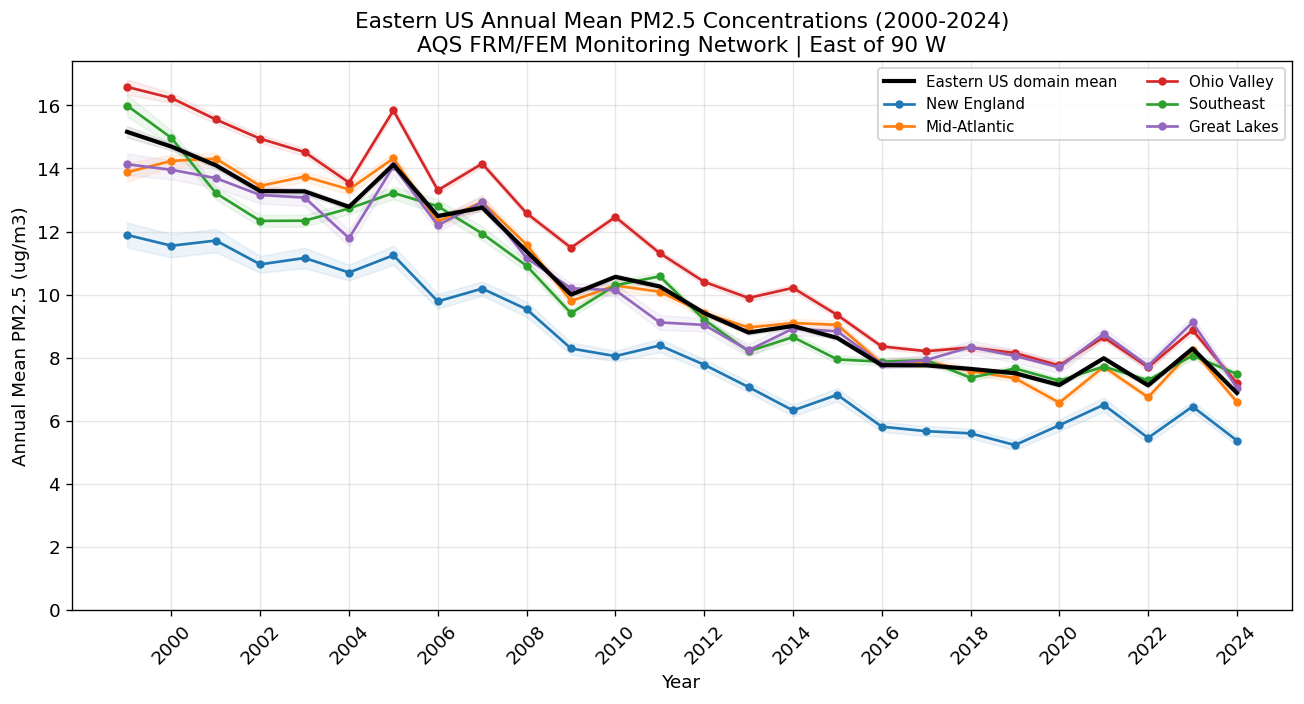

In [6]:
param = 'PM2.5'
if param not in reg:
    print(f'{param} not loaded.')
else:
    df_r = reg[param]
    df_d = dom[param]

    fig, ax = plt.subplots(figsize=(11, 6))

    # Domain-wide mean with ±1 standard error shaded 
    ax.fill_between(df_d['year'], df_d['mean'] - df_d['se'],
                    df_d['mean'] + df_d['se'], color='gray', alpha=0.15)
    ax.plot(df_d['year'], df_d['mean'], 'k-', lw=2.5, zorder=5,
            label='Eastern US domain mean')

    for region, color in REGION_COLORS.items():
        sub = df_r[df_r['region'] == region].sort_values('year')
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['mean'], '-o', color=color,
                lw=1.6, ms=4, label=region)
        ax.fill_between(sub['year'], sub['mean'] - sub['se'],
                        sub['mean'] + sub['se'], color=color, alpha=0.08)

    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Mean PM2.5 (ug/m3)')
    ax.set_title('Eastern US Annual Mean PM2.5 Concentrations (2000-2024)\n'
                 'AQS FRM/FEM Monitoring Network | East of 90 W', fontsize=13)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(START_YEAR, END_YEAR + 1, 2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right', ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '01_pm25_regional_timeseries.png')
    plt.show()

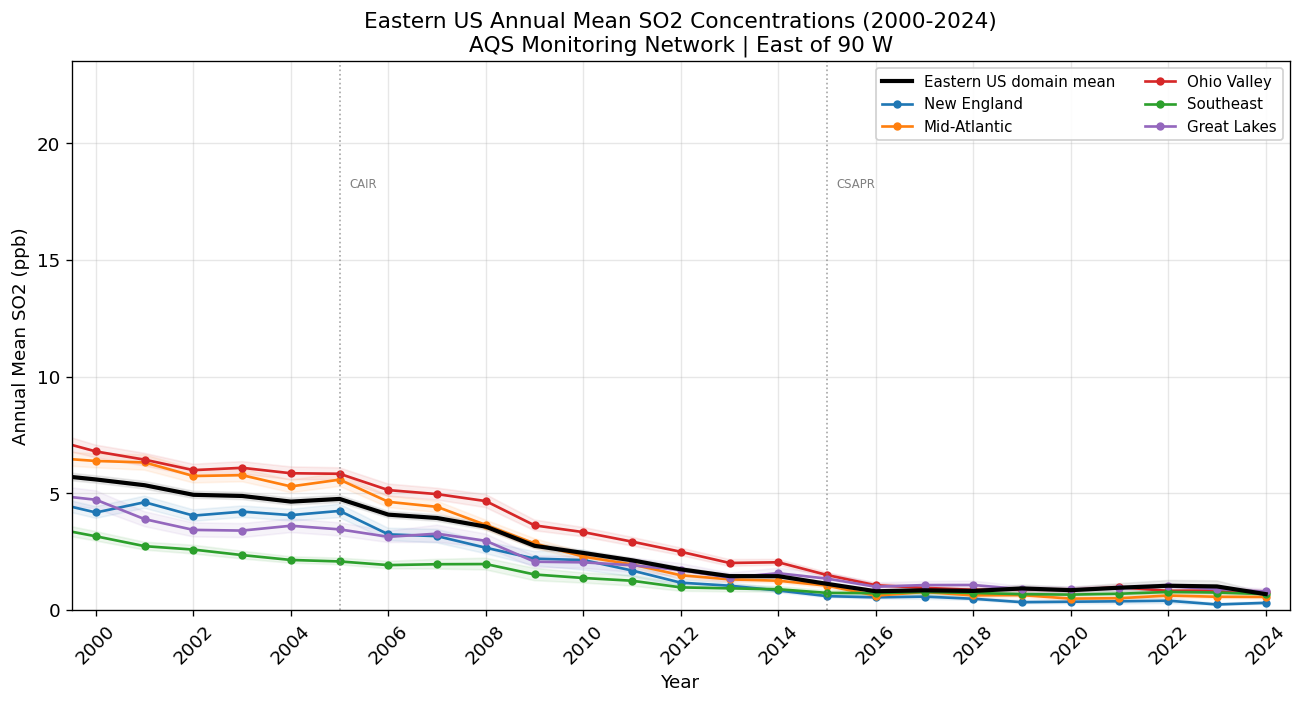

In [7]:
param = 'SO2'
if param not in reg:
    print(f'{param} not loaded.')
else:
    df_r = reg[param]
    df_d = dom[param]

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.fill_between(df_d['year'], df_d['mean'] - df_d['se'],
                    df_d['mean'] + df_d['se'], color='gray', alpha=0.15)
    ax.plot(df_d['year'], df_d['mean'], 'k-', lw=2.5, zorder=5,
            label='Eastern US domain mean')

    for region, color in REGION_COLORS.items():
        sub = df_r[df_r['region'] == region].sort_values('year')
        if sub.empty:
            continue
        ax.plot(sub['year'], sub['mean'], '-o', color=color,
                lw=1.6, ms=4, label=region)
        ax.fill_between(sub['year'], sub['mean'] - sub['se'],
                        sub['mean'] + sub['se'], color=color, alpha=0.08)

    _ymax = df_r['mean'].max()
    ax.axvline(2005, color='gray', ls=':', lw=1.0, alpha=0.7)
    ax.text(2005.2, _ymax * 0.90, 'CAIR',
            fontsize=7, color='gray', va='top')
    ax.axvline(2015, color='gray', ls=':', lw=1.0, alpha=0.7)
    ax.text(2015.2, _ymax * 0.90, 'CSAPR',
            fontsize=7, color='gray', va='top')

    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Mean SO2 (ppb)')
    ax.set_title('Eastern US Annual Mean SO2 Concentrations (2000-2024)\n'
                 'AQS Monitoring Network | East of 90 W', fontsize=13)
    ax.set_xlim(START_YEAR - 0.5, END_YEAR + 0.5)
    ax.set_ylim(bottom=0)
    ax.set_xticks(range(START_YEAR, END_YEAR + 1, 2))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', ncol=2, framealpha=0.9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '02_so2_regional_timeseries.png')
    plt.show()

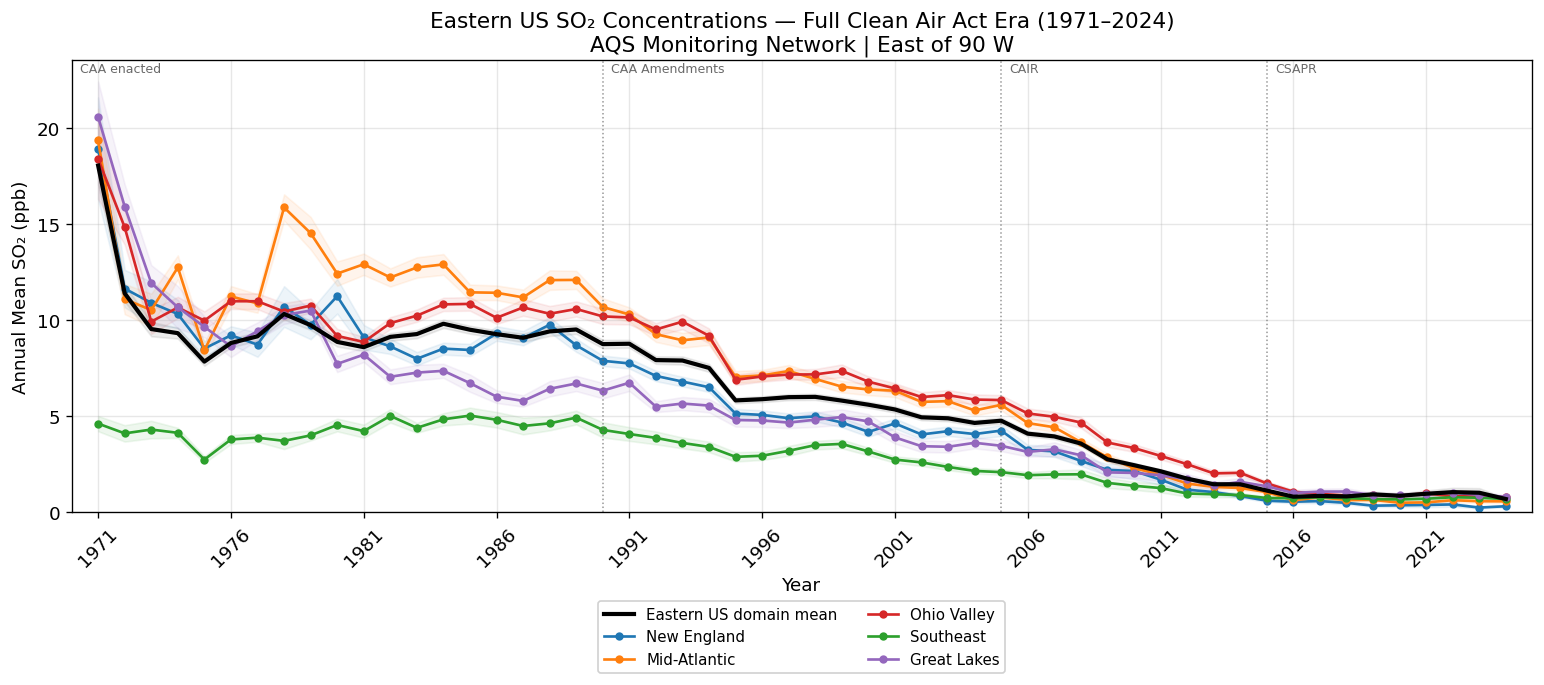

In [8]:
param = 'SO2'

df_r = reg[param]
df_d = dom[param]

fig, ax = plt.subplots(figsize=(13, 6))

ax.fill_between(df_d['year'], df_d['mean'] - df_d['se'],
                df_d['mean'] + df_d['se'], color='gray', alpha=0.15)
ax.plot(df_d['year'], df_d['mean'], 'k-', lw=2.5, zorder=5,
        label='Eastern US domain mean')

for region, color in REGION_COLORS.items():
    sub = df_r[df_r['region'] == region].sort_values('year')
    if sub.empty:
        continue
    ax.plot(sub['year'], sub['mean'], '-o', color=color,
            lw=1.6, ms=4, label=region)
    ax.fill_between(sub['year'], sub['mean'] - sub['se'],
                    sub['mean'] + sub['se'], color=color, alpha=0.08)

_ymax = df_d['mean'].max()

for yr, lbl in [
    (1970, 'CAA enacted'),
    (1990, 'CAA Amendments'),
    (2005, 'CAIR'),
    (2015, 'CSAPR'),
]:
    ax.axvline(yr, color='dimgray', ls=':', lw=0.9, alpha=0.7)
    ax.text(yr + 0.3, _ymax * 1.3, lbl,
            fontsize=7.5, color='dimgray', va='top')

ax.set_xlabel('Year')
ax.set_ylabel('Annual Mean SO₂ (ppb)')
ax.set_title(
    'Eastern US SO₂ Concentrations — Full Clean Air Act Era (1971–2024)\n'
    'AQS Monitoring Network | East of 90 W',
    fontsize=13
)
ax.set_xlim(POLLUTANT_START['SO2'] - 1, END_YEAR + 1)
ax.set_ylim(bottom=0)
ax.set_xticks(range(POLLUTANT_START['SO2'], END_YEAR + 1, 5))
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18), ncol=2, framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '02b_so2_extended_timeseries.png')
plt.show()

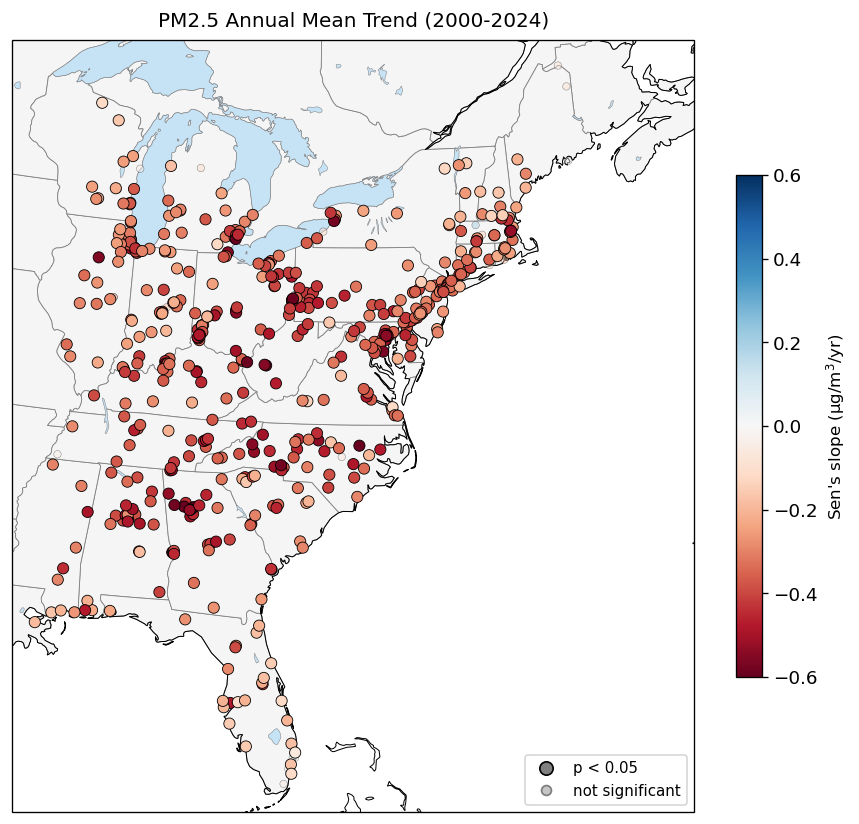

In [9]:
def trend_map(ax, df_t, title, units_per_yr, vmax=None, transform=None):
    df_t = df_t.dropna(subset=['latitude', 'longitude', 'slope']).copy()
    if vmax is None:
        vmax = np.nanpercentile(np.abs(df_t['slope']), 97)
        vmax = min(max(vmax, 0.1), 2.0)

    cmap   = plt.get_cmap('RdBu')
    kwargs = dict(cmap=cmap, vmin=-vmax, vmax=vmax)
    sig    = df_t[df_t['significant']]
    nsig   = df_t[~df_t['significant']]

    scatter_kw = dict(transform=transform) if transform else {}

    ax.scatter(nsig['longitude'], nsig['latitude'], c=nsig['slope'],
               s=20, edgecolors='k', linewidths=0.3, alpha=0.45, zorder=5,
               **kwargs, **scatter_kw)
    sc = ax.scatter(sig['longitude'], sig['latitude'], c=sig['slope'],
                    s=45, edgecolors='k', linewidths=0.5, zorder=6,
                    **kwargs, **scatter_kw)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.03)
    cbar.set_label(f"Sen's slope ({units_per_yr})", fontsize=10)

    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=8, label='p < 0.05'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=6, alpha=0.45, label='not significant'),
    ]
    ax.legend(handles=legend_els, loc='lower right', fontsize=9)
    ax.set_title(title, fontsize=12, pad=8)
    return sc


param = 'PM2.5'
fig = plt.figure(figsize=(12, 7))

proj = ccrs.AlbersEqualArea(central_longitude=-78, central_latitude=37)
ax   = plt.axes(projection=proj)
ax.set_extent([-90, -66, 24, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES.with_scale('50m'),
                edgecolor='gray', linewidth=0.5, facecolor='whitesmoke')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.LAKES.with_scale('50m'),
                facecolor='#c6e2f5', edgecolor='gray', linewidth=0.3)
transform = ccrs.PlateCarree()

trend_map(ax, trends[param],
            title='PM2.5 Annual Mean Trend (2000-2024)',
            units_per_yr=r'$\rm \mu$g/m$^{3}$/yr', vmax=0.6, transform=transform)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_pm25_trend_map.png')
plt.show()

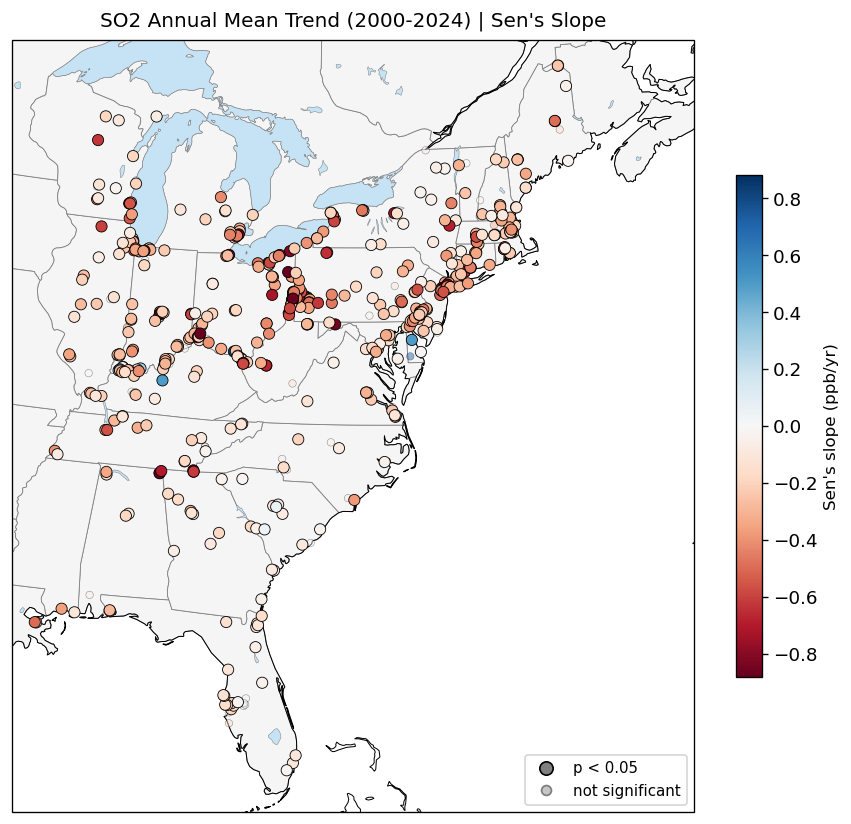

Saved: 04_so2_trend_map.png


In [10]:
param = 'SO2'
fig = plt.figure(figsize=(12, 7))

proj = ccrs.AlbersEqualArea(central_longitude=-78, central_latitude=37)
ax   = plt.axes(projection=proj)
ax.set_extent([-90, -66, 24, 48], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.STATES.with_scale('50m'),
                edgecolor='gray', linewidth=0.5, facecolor='whitesmoke')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax.add_feature(cfeature.LAKES.with_scale('50m'),
                facecolor='#c6e2f5', edgecolor='gray', linewidth=0.3)
transform = ccrs.PlateCarree()

trend_map(ax, trends[param],
            title='SO2 Annual Mean Trend (2000-2024) | Sen\'s Slope',
            units_per_yr='ppb/yr', vmax=None, transform=transform)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_so2_trend_map.png')
plt.show()
print('Saved: 04_so2_trend_map.png')

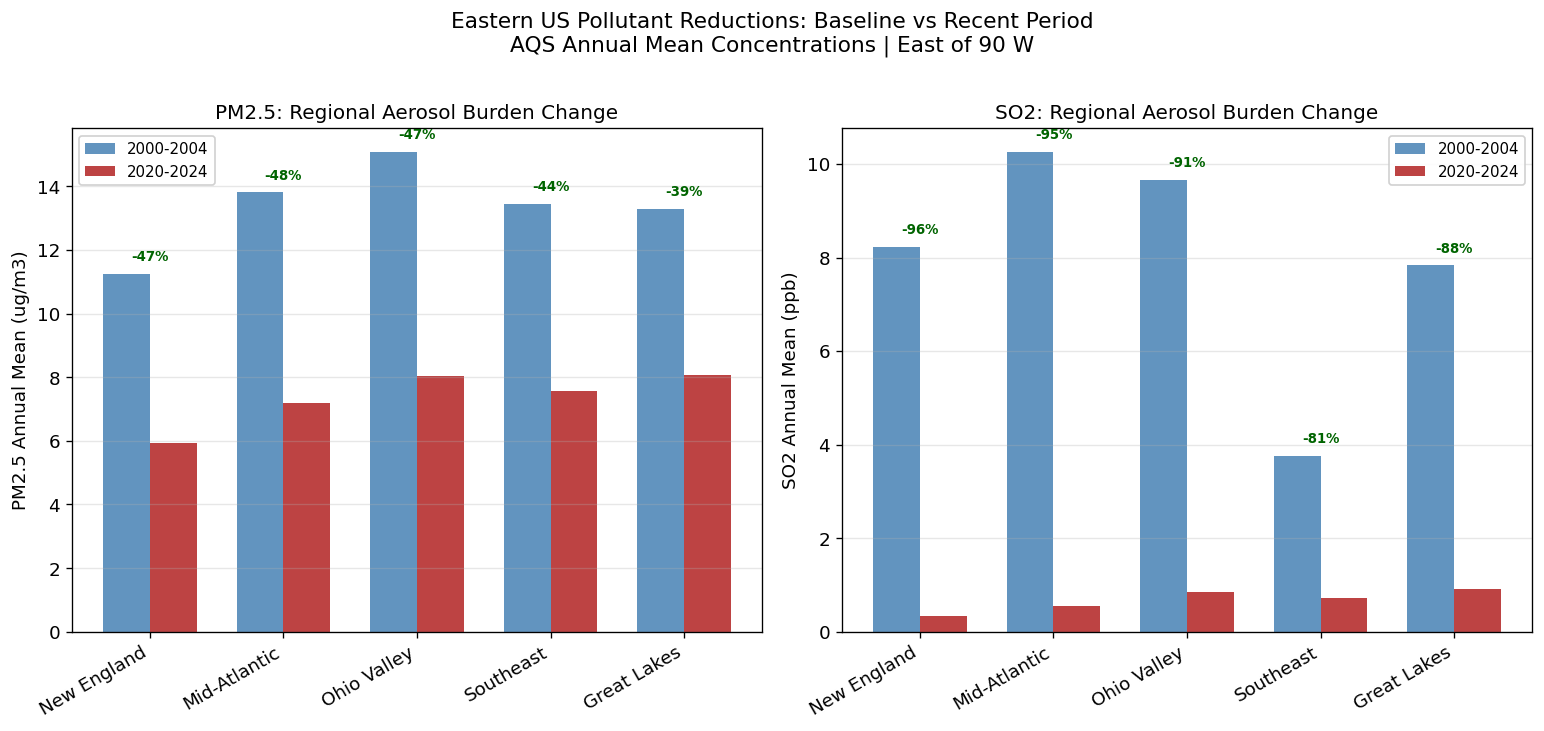

In [11]:
params_to_plot = [p for p in ['PM2.5', 'SO2'] if p in clean]
fig, axes = plt.subplots(1, len(params_to_plot),
                          figsize=(6.5 * len(params_to_plot), 6), sharey=False)
if len(params_to_plot) == 1:
    axes = [axes]

region_order = list(REGIONS.keys())
x = np.arange(len(region_order))
w = 0.35

for ax, param in zip(axes, params_to_plot):
    df = clean[param]
    units = PARAM_UNITS.get(param, '')
    base_means, rec_means = [], []

    for region in region_order:
        sub = df[df['region'] == region]
        base_means.append(sub.loc[sub['year'] <= BASELINE_YRS[1], 'arithmetic_mean'].mean())
        rec_means.append( sub.loc[sub['year'] >= RECENT_YRS[0],   'arithmetic_mean'].mean())

    bars_b = ax.bar(x - w/2, base_means, w,
                    label=f'{BASELINE_YRS[0]}-{BASELINE_YRS[1]}',
                    color='steelblue', alpha=0.85)
    bars_r = ax.bar(x + w/2, rec_means,  w,
                    label=f'{RECENT_YRS[0]}-{RECENT_YRS[1]}',
                    color='firebrick', alpha=0.85)

    ymax = ax.get_ylim()[1]
    for i, (b, r) in enumerate(zip(base_means, rec_means)):
        if pd.notna(b) and pd.notna(r) and b > 0:
            pct = (r - b) / b * 100
            ax.text(i, max(b, r) + ymax * 0.02, f'{pct:+.0f}%',
                    ha='center', va='bottom', fontsize=8,
                    color='darkgreen' if pct < 0 else 'darkred', fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(region_order, rotation=30, ha='right')
    ax.set_ylabel(f'{param} Annual Mean ({units})')
    ax.set_title(f'{param}: Regional Aerosol Burden Change', fontsize=12)
    ax.legend(framealpha=0.9)
    ax.set_ylim(bottom=0)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('Eastern US Pollutant Reductions: Baseline vs Recent Period\n'
             'AQS Annual Mean Concentrations | East of 90 W',
             fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_period_comparison.png', bbox_inches='tight')
plt.show()

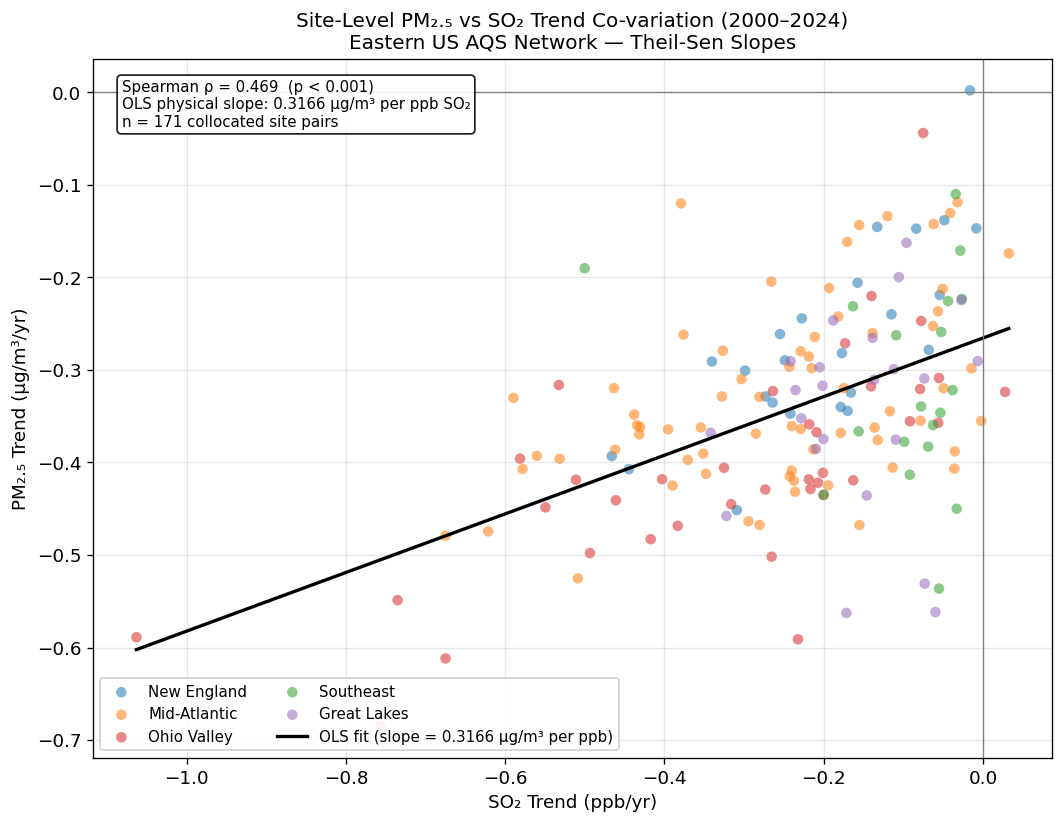

Spearman ρ = 0.469, p = 9.88e-11
OLS slope  = 0.3166 µg/m³ per ppb SO₂  (Pearson r = 0.503)
n = 171 collocated site pairs


In [12]:
df_pm = trends['PM2.5'][['site_id', 'slope', 'region', 'latitude', 'longitude']].copy()
df_so = trends['SO2'][['site_id', 'slope']].copy()
merged = df_pm.merge(df_so, on='site_id', suffixes=('_pm25', '_so2'))
merged = merged.dropna(subset=['slope_pm25', 'slope_so2'])

rho, p_spearman = stats.spearmanr(merged['slope_so2'], merged['slope_pm25'])

slope_r, intercept_r, r_pearson, p_ols, se_r = stats.linregress(
    merged['slope_so2'], merged['slope_pm25'])
x_fit = np.linspace(merged['slope_so2'].min(), merged['slope_so2'].max(), 100)

fig, ax = plt.subplots(figsize=(9, 7))

for region, color in REGION_COLORS.items():
    sub = merged[merged['region'] == region]
    if sub.empty:
        continue
    ax.scatter(sub['slope_so2'], sub['slope_pm25'],
                color=color, alpha=0.55, s=40, label=region, edgecolors='none')

ax.plot(x_fit, slope_r * x_fit + intercept_r, 'k-', lw=2,
        label=f'OLS fit (slope = {slope_r:.4f} µg/m³ per ppb)')

ax.axhline(0, color='gray', lw=0.8, ls='-')
ax.axvline(0, color='gray', lw=0.8, ls='-')

ax.set_xlabel('SO₂ Trend (ppb/yr)', fontsize=11)
ax.set_ylabel('PM₂.₅ Trend (µg/m³/yr)', fontsize=11)
ax.set_title(
    'Site-Level PM₂.₅ vs SO₂ Trend Co-variation (2000–2024)\n'
    'Eastern US AQS Network — Theil-Sen Slopes', fontsize=12)
ax.legend(ncol=2, fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)

sig_str = '< 0.001' if p_spearman < 0.001 else f'= {p_spearman:.3f}'
ax.text(
    0.03, 0.97,
    f'Spearman ρ = {rho:.3f}  (p {sig_str})\n'
    f'OLS physical slope: {slope_r:.4f} µg/m³ per ppb SO₂\n'
    f'n = {len(merged)} collocated site pairs',
    transform=ax.transAxes, fontsize=9, va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.9)
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / '06_pm25_so2_trend_correlation.png')
plt.show()
print(f'Spearman ρ = {rho:.3f}, p = {p_spearman:.3g}')
print(f'OLS slope  = {slope_r:.4f} µg/m³ per ppb SO₂  (Pearson r = {r_pearson:.3f})')
print(f'n = {len(merged)} collocated site pairs')


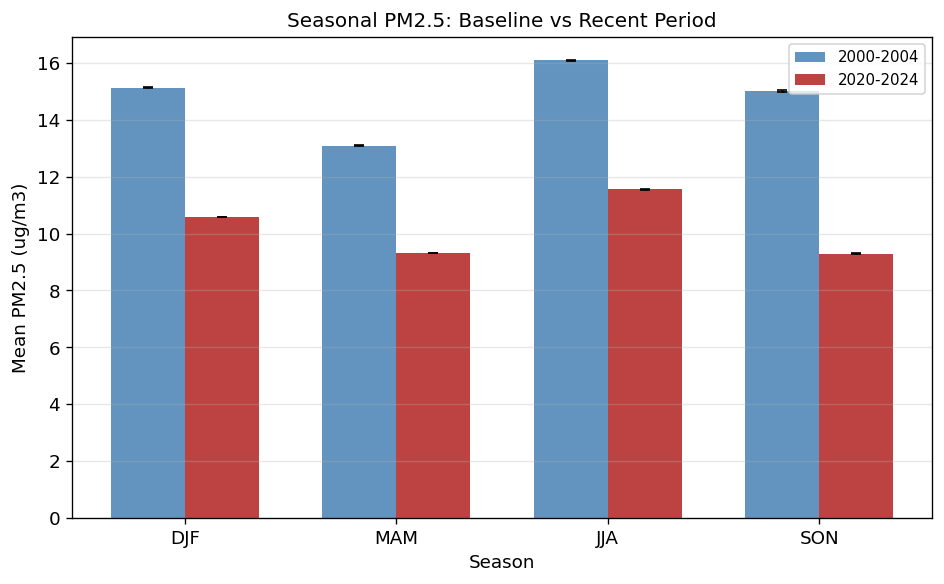

In [13]:
DAILY_DIR = Path('data/raw/daily')
SEASONS   = {'DJF': [12, 1, 2], 'MAM': [3, 4, 5],
             'JJA': [6, 7, 8],  'SON': [9, 10, 11]}

daily_frames = []
if DAILY_DIR.exists():
    for f in DAILY_DIR.glob('daily_PM2.5_*.csv'):
        try:
            daily_frames.append(pd.read_csv(f, low_memory=False))
        except Exception:
            pass

if not daily_frames:
    print('No daily PM2.5 files found in data/raw/daily/.')
    print('To enable seasonal analysis, download daily data for select years:')
    print('  See the optional daily-download cell in 01_aqs_eastern_us_download.ipynb')
else:
    df_daily = pd.concat(daily_frames, ignore_index=True)
    df_daily['date']  = pd.to_datetime(df_daily['date_local'], errors='coerce')
    df_daily['month'] = df_daily['date'].dt.month
    df_daily['year']  = df_daily['date'].dt.year
    df_daily['arithmetic_mean'] = pd.to_numeric(
        df_daily.get('arithmetic_mean', np.nan), errors='coerce')
    df_daily = df_daily[df_daily['longitude'] >= MIN_LON]

    def month_to_season(m):
        for s, months in SEASONS.items():
            if m in months:
                return s
        return None

    df_daily['season'] = df_daily['month'].map(month_to_season)
    df_daily['period'] = np.where(df_daily['year'] <= BASELINE_YRS[1], 'baseline', 'recent')
    df_daily = df_daily[df_daily['period'].isin(['baseline', 'recent'])]

    season_means = (
        df_daily.groupby(['period', 'season'])['arithmetic_mean']
        .agg(mean='mean', std='std', n='count')
        .reset_index()
        .assign(se=lambda x: x['std'] / np.sqrt(x['n']))
    )

    season_order = ['DJF', 'MAM', 'JJA', 'SON']
    x = np.arange(len(season_order))
    w = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))
    for i, (period, color, label) in enumerate([
        ('baseline', 'steelblue', f'{BASELINE_YRS[0]}-{BASELINE_YRS[1]}'),
        ('recent',   'firebrick', f'{RECENT_YRS[0]}-{RECENT_YRS[1]}'),
    ]):
        sub = season_means[season_means['period'] == period].set_index('season')
        means = [sub.loc[s, 'mean'] if s in sub.index else np.nan for s in season_order]
        errs  = [sub.loc[s, 'se']   if s in sub.index else 0       for s in season_order]
        ax.bar(x + (i - 0.5) * w, means, w, yerr=errs, capsize=3,
               color=color, alpha=0.85, label=label)

    ax.set_xticks(x)
    ax.set_xticklabels(season_order)
    ax.set_xlabel('Season')
    ax.set_ylabel('Mean PM2.5 (ug/m3)')
    ax.set_title('Seasonal PM2.5: Baseline vs Recent Period', fontsize=12)
    ax.legend(); ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '07_pm25_seasonal_comparison.png')
    plt.show()

In [14]:
def regional_mk_trend(df, region):
    """Mann-Kendall + Sen slope on the region-level annual mean time series."""
    sub = df[df['region'] == region].sort_values('year')
    yr_mean = sub.groupby('year')['arithmetic_mean'].mean().dropna()
    if len(yr_mean) < 10:
        return np.nan, np.nan, np.nan, np.nan
    yrs  = yr_mean.index.values.astype(float)
    vals = yr_mean.values
    _, p = stats.kendalltau(yrs, vals)
    ts   = stats.theilslopes(vals, yrs, 0.95)
    return ts.slope, p, ts.low_slope, ts.high_slope


region_order = list(REGIONS.keys())
rows = []
for param in ['PM2.5', 'SO2']:
    if param not in clean:
        continue
    df    = clean[param]
    units = PARAM_UNITS.get(param, '')

    for region in region_order:
        slope, p, sl, sh = regional_mk_trend(df, region)
        sub = df[df['region'] == region]

        base   = sub.loc[sub['year'] <= BASELINE_YRS[1], 'arithmetic_mean'].mean()
        recent = sub.loc[sub['year'] >= RECENT_YRS[0],   'arithmetic_mean'].mean()
        pct    = (recent - base) / base * 100 if pd.notna(base) and base > 0 else np.nan

        param_trends = trends.get(param, pd.DataFrame())
        if not param_trends.empty and 'region' in param_trends.columns:
            n_sites_trend = (param_trends['region'] == region).sum()
        else:
            n_sites_trend = 0

        rows.append({
            'Param':            param,
            'Units':            units,
            'Region':           region,
            'N sites (trend)':  n_sites_trend,
            'Baseline mean':    round(base,   3) if pd.notna(base)  else np.nan,
            'Recent mean':      round(recent, 3) if pd.notna(recent) else np.nan,
            '% change':         f'{pct:+.1f}%' if pd.notna(pct) else 'N/A',
            'Sen slope':        round(slope,  4) if pd.notna(slope) else np.nan,
            'Slope CI low':     round(sl,     4) if pd.notna(sl)    else np.nan,
            'Slope CI high':    round(sh,     4) if pd.notna(sh)    else np.nan,
            'MK p-value':       round(p,      3) if pd.notna(p)     else np.nan,
            'Significant':      'Yes' if pd.notna(p) and p < 0.05 else 'No',
        })

summary = pd.DataFrame(rows)
summary.to_csv(PROCESSED_DIR / 'regional_trend_summary.csv', index=False)

for param in ['PM2.5', 'SO2']:
    sub = summary[summary['Param'] == param].copy()
    if sub.empty:
        continue
    units = sub['Units'].iloc[0]
    sub = sub.drop(columns=['Param', 'Units'])

    sub['95% CI'] = sub.apply(
        lambda r: f'[{r["Slope CI low"]:.4f}, {r["Slope CI high"]:.4f}]'
                  if pd.notna(r['Slope CI low']) else 'N/A', axis=1
    )
    sub = sub.drop(columns=['Slope CI low', 'Slope CI high'])

    sub = sub.rename(columns={
        'Baseline mean': f'Baseline ({units})',
        'Recent mean':   f'Recent ({units})',
        'Sen slope':     f'Slope ({units}/yr)',
    })

    print(f'\n{"="*80}')
    print(f'  {param} Regional Trend Summary')
    print(f'{"="*80}')
    print(sub.to_string(index=False))



  PM2.5 Regional Trend Summary
      Region  N sites (trend)  Baseline (ug/m3)  Recent (ug/m3) % change  Slope (ug/m3/yr)  MK p-value Significant             95% CI
 New England               55            11.254           5.937   -47.2%           -0.3063         0.0         Yes [-0.3524, -0.2539]
Mid-Atlantic              136            13.811           7.184   -48.0%           -0.3480         0.0         Yes [-0.3994, -0.3019]
 Ohio Valley              144            15.072           8.040   -46.7%           -0.3982         0.0         Yes [-0.4397, -0.3487]
   Southeast              141            13.438           7.568   -43.7%           -0.3156         0.0         Yes [-0.3833, -0.2543]
 Great Lakes               75            13.281           8.070   -39.2%           -0.2930         0.0         Yes [-0.3469, -0.2278]

  SO2 Regional Trend Summary
      Region  N sites (trend)  Baseline (ppb)  Recent (ppb) % change  Slope (ppb/yr)  MK p-value Significant             95% CI
 New E

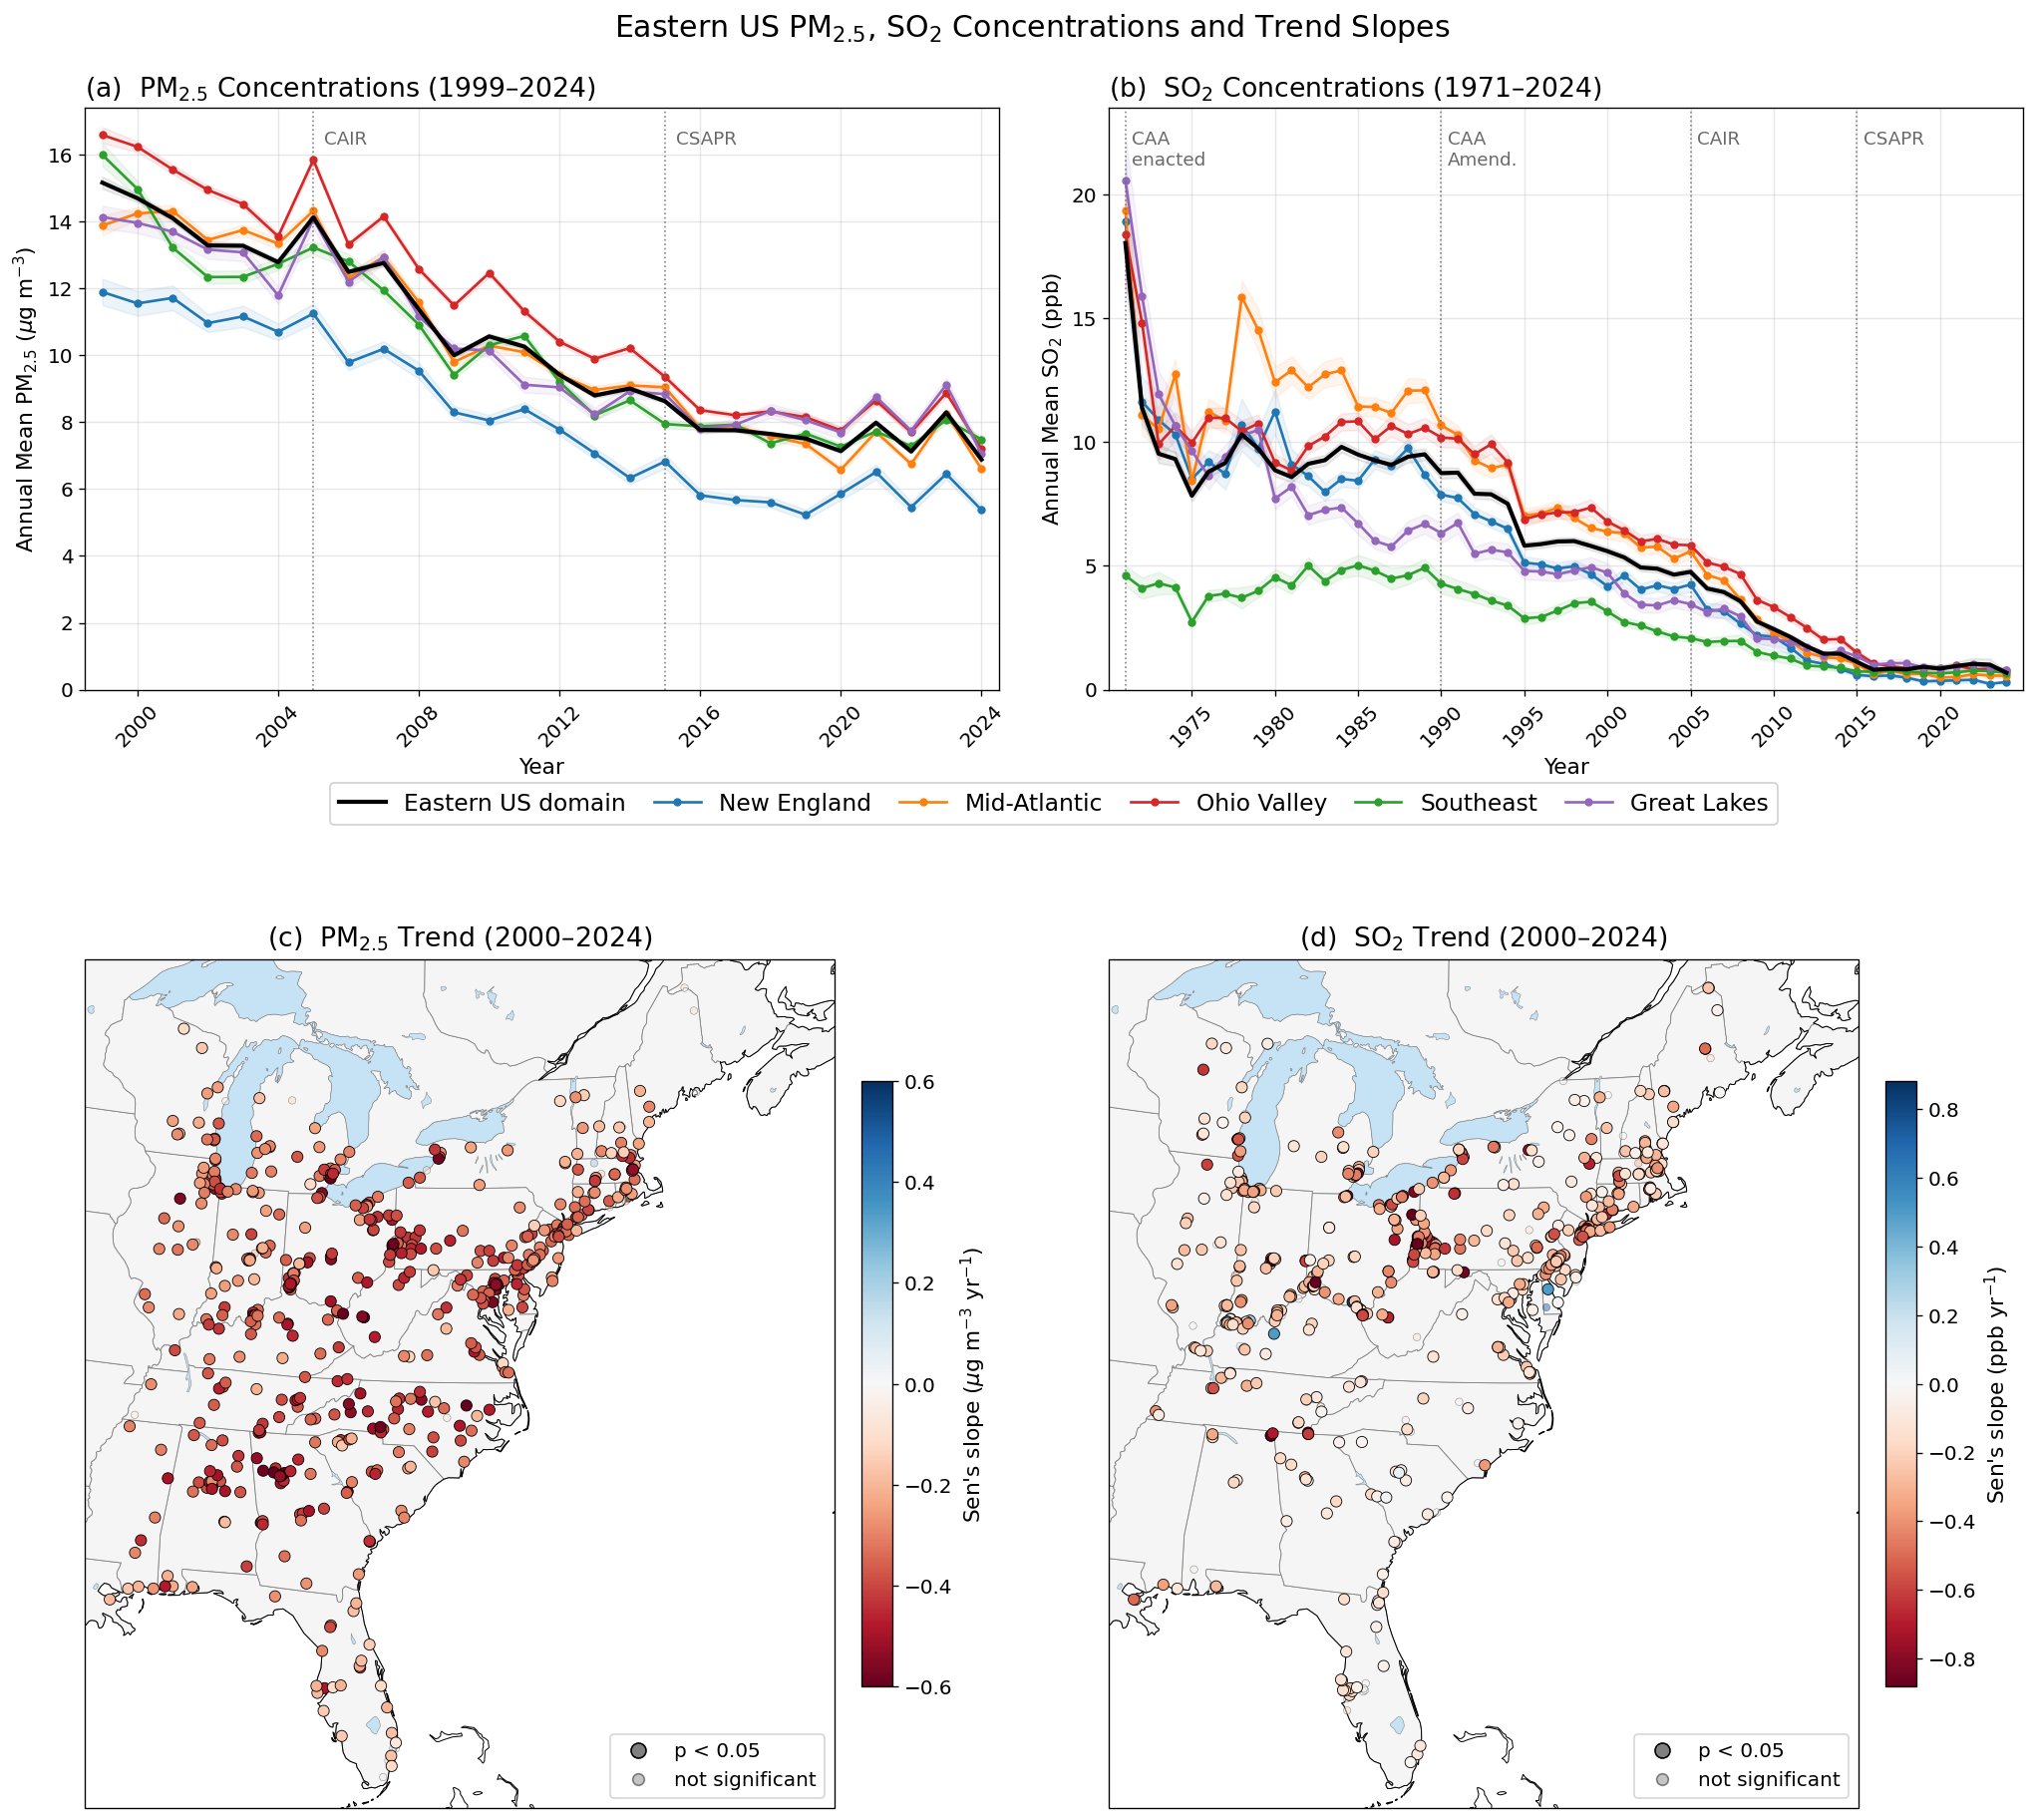

In [15]:
# ── Figure 1: 4-panel — Time Series (top) + Trend Maps (bottom) ──────────────

# ── redef trend map to adjust fontsizes
def trend_map(ax, df_t, title, units_per_yr, vmax=None, transform=None):
    df_t = df_t.dropna(subset=['latitude', 'longitude', 'slope']).copy()
    if vmax is None:
        vmax = np.nanpercentile(np.abs(df_t['slope']), 97)
        vmax = min(max(vmax, 0.1), 2.0)

    cmap   = plt.get_cmap('RdBu')
    kwargs = dict(cmap=cmap, vmin=-vmax, vmax=vmax)
    sig    = df_t[df_t['significant']]
    nsig   = df_t[~df_t['significant']]

    scatter_kw = dict(transform=transform) if transform else {}

    ax.scatter(nsig['longitude'], nsig['latitude'], c=nsig['slope'],
               s=20, edgecolors='k', linewidths=0.3, alpha=0.45, zorder=5,
               **kwargs, **scatter_kw)
    sc = ax.scatter(sig['longitude'], sig['latitude'], c=sig['slope'],
                    s=45, edgecolors='k', linewidths=0.5, zorder=6,
                    **kwargs, **scatter_kw)

    cbar = plt.colorbar(sc, ax=ax, shrink=0.65, pad=0.03)
    cbar.set_label(f"Sen's slope ({units_per_yr})", fontsize=13)
    cbar.ax.tick_params(labelsize=12)

    legend_els = [
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=9, label='p < 0.05'),
        Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',
               markeredgecolor='k', markersize=7, alpha=0.45, label='not significant'),
    ]
    ax.legend(handles=legend_els, loc='lower right', fontsize=12)
    ax.set_title(title, fontsize=16, pad=8)
    return sc

PLOT_REGIONS = [r for r in REGION_COLORS if r != 'South-Central']
proj      = ccrs.AlbersEqualArea(central_longitude=-78, central_latitude=37)
transform = ccrs.PlateCarree()
extent    = [-90, -66, 24, 48]

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(3, 2, figure=fig,
                         height_ratios=[1.0, 0.12, 1.6],
                         hspace=0.15, wspace=0.12,
                         top=0.93, bottom=0.02, left=0.06, right=0.96)

ax_a   = fig.add_subplot(gs[0, 0])
ax_b   = fig.add_subplot(gs[0, 1])
ax_leg = fig.add_subplot(gs[1, :])
ax_leg.axis('off')
ax_c   = fig.add_subplot(gs[2, 0], projection=proj)
ax_d   = fig.add_subplot(gs[2, 1], projection=proj)

# ── (a) PM2.5 Time Series ─────────────────────────────────────────────────────
df_r, df_d = reg['PM2.5'], dom['PM2.5']
ax_a.fill_between(df_d['year'], df_d['mean'] - df_d['se'],
                   df_d['mean'] + df_d['se'], color='gray', alpha=0.15)
ax_a.plot(df_d['year'], df_d['mean'], 'k-', lw=2.5, zorder=5, label='Eastern US domain')
for region in PLOT_REGIONS:
    sub = df_r[df_r['region'] == region].sort_values('year')
    if sub.empty: continue
    ax_a.plot(sub['year'], sub['mean'], '-o', color=REGION_COLORS[region],
              lw=1.6, ms=4, label=region)
    ax_a.fill_between(sub['year'], sub['mean'] - sub['se'],
                       sub['mean'] + sub['se'], color=REGION_COLORS[region], alpha=0.08)
for yr, lbl in [(2005, 'CAIR'), (2015, 'CSAPR')]:
    ax_a.axvline(yr, color='dimgray', ls=':', lw=1.0, alpha=0.8)
    ax_a.text(yr + 0.3, 0.96, lbl, transform=ax_a.get_xaxis_transform(),
              fontsize=11, color='dimgray', va='top')
ax_a.set_xlabel('Year', fontsize=13)
ax_a.set_ylabel(r'Annual Mean PM$_{2.5}$ ($\mu$g m$^{-3}$)', fontsize=13)
ax_a.set_title(r'(a)  PM$_{2.5}$ Concentrations (1999–2024)', fontsize=16, loc='left')
ax_a.set_xlim(1998.5, END_YEAR + 0.5); ax_a.set_ylim(bottom=0)
ax_a.set_xticks(range(2000, END_YEAR + 1, 4))
ax_a.tick_params(axis='both', labelsize=12)
ax_a.tick_params(axis='x', rotation=45)
ax_a.grid(True, alpha=0.3)
handles_ts, labels_ts = ax_a.get_legend_handles_labels()

# ── (b) SO2 Time Series ───────────────────────────────────────────────────────
df_r, df_d = reg['SO2'], dom['SO2']
ax_b.fill_between(df_d['year'], df_d['mean'] - df_d['se'],
                   df_d['mean'] + df_d['se'], color='gray', alpha=0.15)
ax_b.plot(df_d['year'], df_d['mean'], 'k-', lw=2.5, zorder=5)
for region in PLOT_REGIONS:
    sub = df_r[df_r['region'] == region].sort_values('year')
    if sub.empty: continue
    ax_b.plot(sub['year'], sub['mean'], '-o', color=REGION_COLORS[region], lw=1.6, ms=4)
    ax_b.fill_between(sub['year'], sub['mean'] - sub['se'],
                       sub['mean'] + sub['se'], color=REGION_COLORS[region], alpha=0.08)
for yr, lbl in [(1971, 'CAA\nenacted'), (1990, 'CAA\nAmend.'), (2005, 'CAIR'), (2015, 'CSAPR')]:
    ax_b.axvline(yr, color='dimgray', ls=':', lw=1.0, alpha=0.8)
    ax_b.text(yr + 0.4, 0.96, lbl, transform=ax_b.get_xaxis_transform(),
              fontsize=11, color='dimgray', va='top')
ax_b.set_xlabel('Year', fontsize=13)
ax_b.set_ylabel('Annual Mean SO$_2$ (ppb)', fontsize=13)
ax_b.set_title('(b)  SO$_2$ Concentrations (1971–2024)', fontsize=16, loc='left')
ax_b.set_xlim(POLLUTANT_START['SO2'] - 1, END_YEAR + 1); ax_b.set_ylim(bottom=0)
ax_b.set_xticks(range(1975, END_YEAR + 1, 5))
ax_b.tick_params(axis='both', labelsize=12)
ax_b.tick_params(axis='x', rotation=45)
ax_b.grid(True, alpha=0.3)

ax_leg.legend(handles_ts, labels_ts,
              loc='center', ncol=6,
              bbox_to_anchor=(0.5, 0.5),
              bbox_transform=ax_leg.transAxes,
              framealpha=0.9, fontsize=14,
              handlelength=2.0, columnspacing=1.2)

# ── (c) PM2.5 Trend Map ───────────────────────────────────────────────────────
ax_c.set_extent(extent, crs=transform)
ax_c.add_feature(cfeature.STATES.with_scale('50m'),
                  edgecolor='gray', linewidth=0.5, facecolor='whitesmoke')
ax_c.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax_c.add_feature(cfeature.LAKES.with_scale('50m'),
                  facecolor='#c6e2f5', edgecolor='gray', linewidth=0.3)
trend_map(ax_c, trends['PM2.5'],
          title=r'(c)  PM$_{2.5}$ Trend (2000–2024)',
          units_per_yr=r'$\mu$g m$^{-3}$ yr$^{-1}$', vmax=0.6, transform=transform)

# ── (d) SO2 Trend Map ─────────────────────────────────────────────────────────
ax_d.set_extent(extent, crs=transform)
ax_d.add_feature(cfeature.STATES.with_scale('50m'),
                  edgecolor='gray', linewidth=0.5, facecolor='whitesmoke')
ax_d.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6)
ax_d.add_feature(cfeature.LAKES.with_scale('50m'),
                  facecolor='#c6e2f5', edgecolor='gray', linewidth=0.3)
trend_map(ax_d, trends['SO2'],
          title=r'(d)  SO$_2$ Trend (2000–2024)',
          units_per_yr=r'ppb yr$^{-1}$', vmax=None, transform=transform)

# ── Title ─────────────────────────────────────────────────────────────────────
fig.suptitle(
    'Eastern US PM$_{2.5}$, SO$_2$ Concentrations and Trend Slopes',
    fontsize=18
)
plt.savefig(FIGURES_DIR / 'fig1_timeseries_and_maps.png', dpi=300, bbox_inches='tight')
plt.show()


Loading speciation CSVs...
  SO4: 3,328 site-years | 275 sites
  NO3: 3,292 site-years | 268 sites
  OC: 994 site-years | 197 sites
  EC: 1,029 site-years | 197 sites
  NH4: 2,454 site-years | 239 sites
spec_wide: 973 site-years | 194 sites
Computing Theil-Sen slopes per species...
Done: 34 sites with ≥8 years


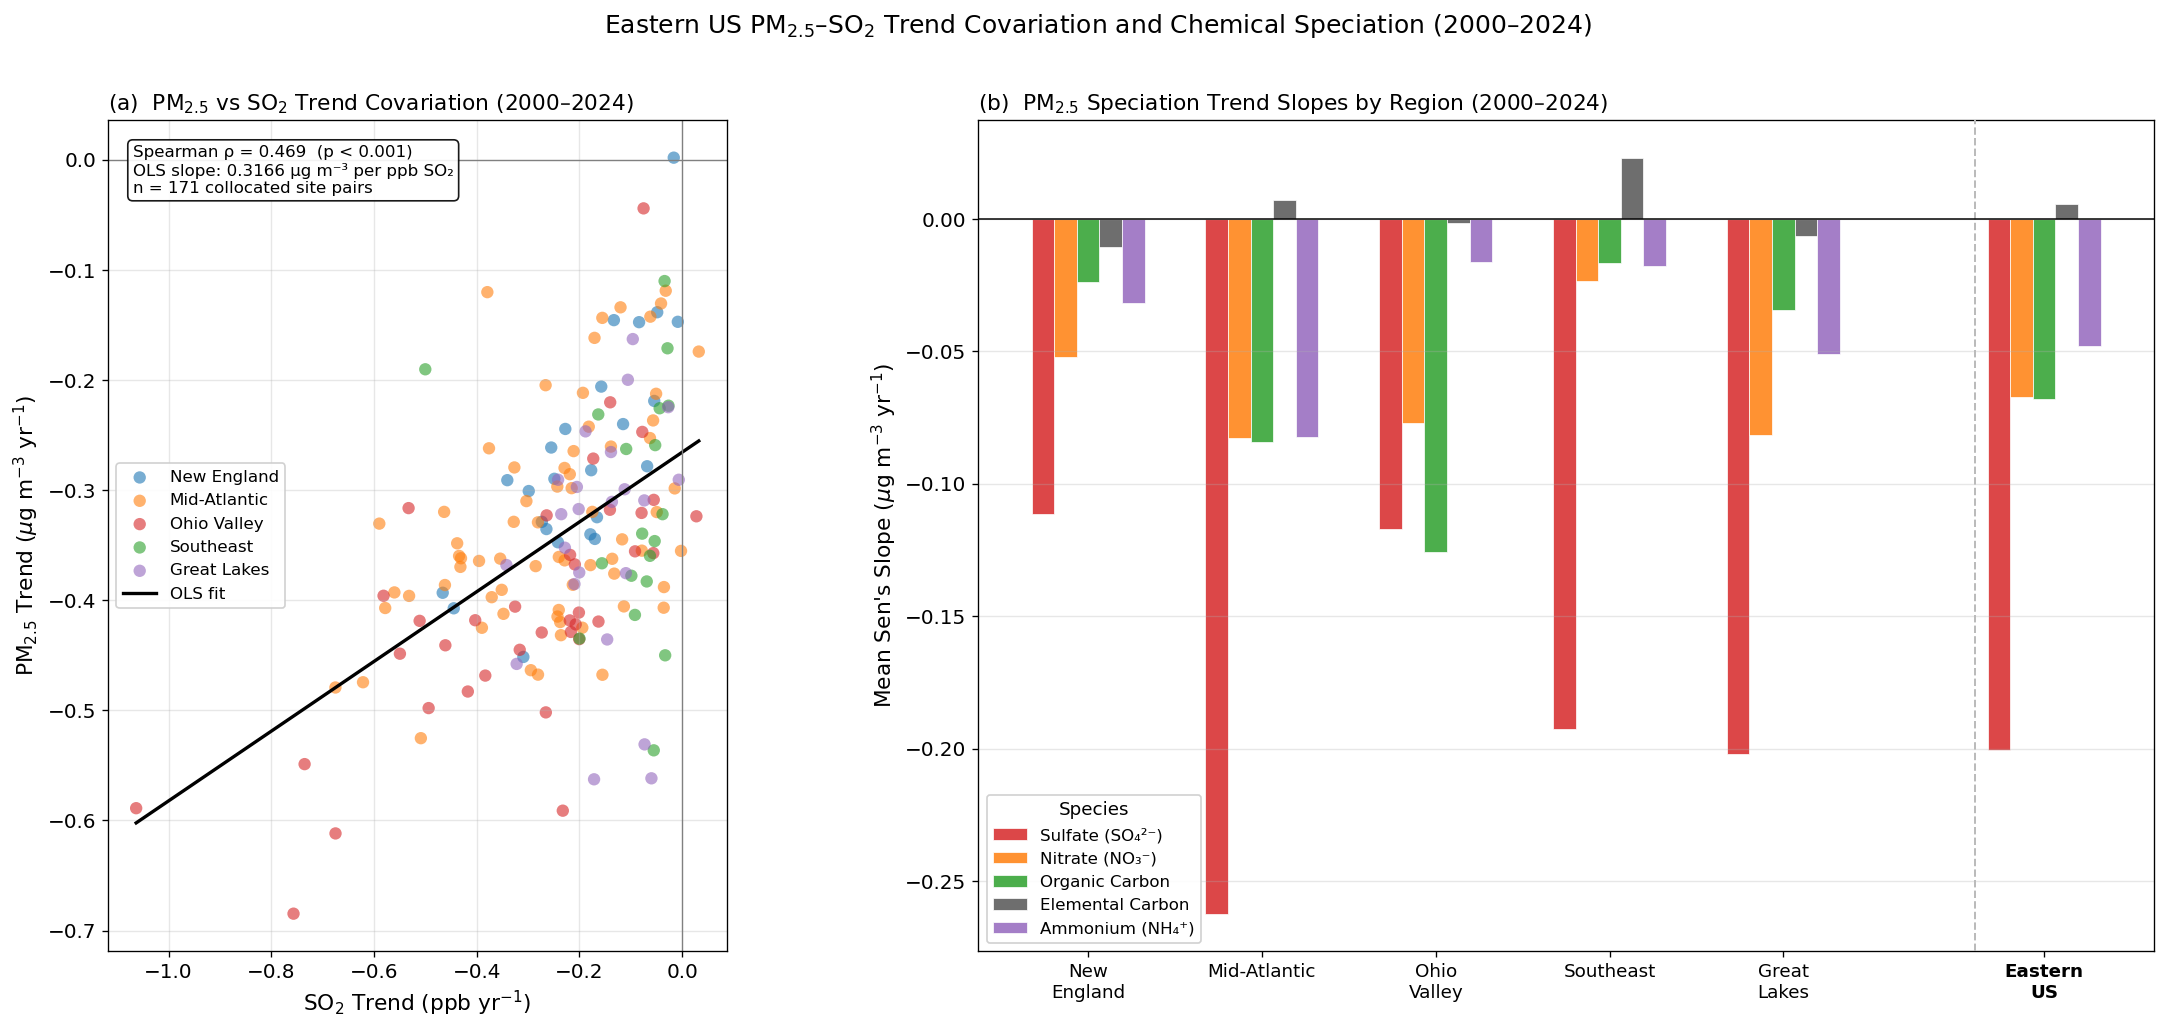

In [16]:
# ── Figure 2: PM2.5–SO2 Scatter (a) + Speciation Trends (b) ──────────────────

# ── 1. Species metadata ───────────────────────────────────────────────────────
if 'SPECIES_ORDER' not in dir():
    SPECIES_ORDER = ['SO4', 'NO3', 'OC', 'EC', 'NH4']
if 'SPECIES_META' not in dir():
    SPECIES_META = {
        'SO4': {'label': 'Sulfate (SO₄²⁻)',  'color': '#d62728'},
        'NO3': {'label': 'Nitrate (NO₃⁻)',   'color': '#ff7f0e'},
        'OC':  {'label': 'Organic Carbon',    'color': '#2ca02c'},
        'EC':  {'label': 'Elemental Carbon',  'color': '#555555'},
        'NH4': {'label': 'Ammonium (NH₄⁺)',  'color': '#9467bd'},
    }

# ── 2. spec_wide: load speciation CSVs if not in namespace ───────────────────
if 'spec_wide' not in dir():
    print('Loading speciation CSVs...')
    _SPEC_DIR = Path('/data/keeling/a/daquino2/b/atms507/proj/data/processed')
    _FIPS = {
        '01':'AL','05':'AR','09':'CT','11':'DC','10':'DE','12':'FL','13':'GA',
        '17':'IL','18':'IN','21':'KY','22':'LA','23':'ME','24':'MD','25':'MA',
        '26':'MI','28':'MS','29':'MO','33':'NH','34':'NJ','36':'NY','37':'NC',
        '39':'OH','42':'PA','44':'RI','45':'SC','47':'TN','50':'VT','51':'VA',
        '54':'WV','55':'WI',
    }
    _FILES = {
        'SO4': _SPEC_DIR / 'PM25_SO4_annual_1999_2024_eastern_us.csv',
        'NO3': _SPEC_DIR / 'PM25_NO3_annual_1999_2024_eastern_us.csv',
        'OC':  _SPEC_DIR / 'PM25_OC_annual_1999_2024_eastern_us.csv',
        'EC':  _SPEC_DIR / 'PM25_EC_annual_1999_2024_eastern_us.csv',
        'NH4': _SPEC_DIR / 'PM25_NH4_annual_1999_2024_eastern_us.csv',
    }
    _MAX = {'SO4': 30, 'NO3': 20, 'OC': 25, 'EC': 10, 'NH4': 15}

    def _load_spec(fpath, sp_col):
        d = pd.read_csv(fpath, low_memory=False,
                        dtype={'state_code': str, 'county_code': str, 'site_number': str})
        d['site_id'] = (d['state_code'].str.zfill(2) + '-' +
                        d['county_code'].str.zfill(3) + '-' +
                        d['site_number'].str.zfill(4))
        for col in ['year', 'arithmetic_mean', 'longitude', 'poc', 'observation_percent']:
            d[col] = pd.to_numeric(d[col], errors='coerce')
        d['poc'] = d['poc'].fillna(1)
        d = d[(d['longitude'] >= -90.0) &
              (d['arithmetic_mean'].between(0, _MAX.get(sp_col, 50), inclusive='right')) &
              (d['observation_percent'] >= 75)]
        abbr = (d['state_abbr'] if 'state_abbr' in d.columns
                else d['state_code'].str.zfill(2).map(_FIPS))
        d['state_abbr'] = abbr
        d['region'] = abbr.map(STATE_TO_REGION)
        d = d[d['region'].notna()]
        d = (d.sort_values('poc')
              .drop_duplicates(subset=['site_id', 'year'], keep='first'))
        return (d[['site_id', 'year', 'arithmetic_mean',
                   'latitude', 'longitude', 'state_abbr', 'region']]
                 .rename(columns={'arithmetic_mean': sp_col})
                 .reset_index(drop=True))

    _sdfs = {}
    for sp, fp in _FILES.items():
        _sdfs[sp] = _load_spec(fp, sp)
        print(f'  {sp}: {len(_sdfs[sp]):,} site-years | {_sdfs[sp]["site_id"].nunique()} sites')

    spec_wide = _sdfs['SO4'][
        ['site_id', 'year', 'latitude', 'longitude', 'state_abbr', 'region', 'SO4']].copy()
    for sp in ['NO3', 'OC', 'EC']:
        spec_wide = spec_wide.merge(
            _sdfs[sp][['site_id', 'year', sp]], on=['site_id', 'year'], how='inner')
    spec_wide = spec_wide.merge(
        _sdfs['NH4'][['site_id', 'year', 'NH4']], on=['site_id', 'year'], how='left')
    print(f'spec_wide: {len(spec_wide):,} site-years | {spec_wide["site_id"].nunique()} sites')

# ── 3. spec_slopes / reg_sp_slopes ───────────────────────────────────────────
if 'spec_slopes' not in dir() or 'reg_sp_slopes' not in dir():
    print('Computing Theil-Sen slopes per species...')
    _MIN_SPEC_YRS = 8
    _rec = []
    for sid, grp in spec_wide.groupby('site_id'):
        grp = grp.sort_values('year')
        if len(grp) < _MIN_SPEC_YRS:
            continue
        yrs = grp['year'].values
        row = {'site_id': sid, 'region': grp['region'].iloc[0]}
        for sp in SPECIES_ORDER:
            vals = grp[sp].values
            mask = ~np.isnan(vals)
            if mask.sum() >= _MIN_SPEC_YRS:
                row[f'slope_{sp}'] = stats.theilslopes(vals[mask], yrs[mask]).slope
            else:
                row[f'slope_{sp}'] = np.nan
        _rec.append(row)
    spec_slopes = pd.DataFrame(_rec)
    reg_sp_slopes = (spec_slopes
                     .groupby('region')[[f'slope_{sp}' for sp in SPECIES_ORDER]]
                     .mean()
                     .rename(columns={f'slope_{sp}': sp for sp in SPECIES_ORDER}))
    print(f'Done: {len(spec_slopes)} sites with ≥{_MIN_SPEC_YRS} years')
else:
    print(f'Using existing spec_slopes ({len(spec_slopes)} sites)')

# ── Load scatter data from this notebook's trend CSVs ────────────────────────
_pm_t  = pd.read_csv(PROCESSED_DIR / 'PM2.5_site_trends.csv')
_so2_t = pd.read_csv(PROCESSED_DIR / 'SO2_site_trends.csv')[['site_id', 'slope']]
_mrg   = (_pm_t.merge(_so2_t, on='site_id', suffixes=('_pm25', '_so2'))
                .dropna(subset=['slope_pm25', 'slope_so2']))

rho, p_sp                = spearmanr(_mrg['slope_so2'], _mrg['slope_pm25'])
slope_r, intercept_r, *_ = linregress(_mrg['slope_so2'], _mrg['slope_pm25'])
x_fit = np.linspace(_mrg['slope_so2'].min(), _mrg['slope_so2'].max(), 100)

REGION_ORDER_6 = list(REGIONS.keys())
PLOT_REGIONS_5 = [r for r in REGION_ORDER_6 if r != 'South-Central']

# ── Layout: 1×2, scatter narrow, bar chart wide ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 9),
                          gridspec_kw={'width_ratios': [1, 1.9], 'wspace': 0.28})

# ── (a) Scatter: site-level PM2.5 vs SO2 Theil-Sen slopes ────────────────────
ax = axes[0]
for region in PLOT_REGIONS_5:
    sub = _mrg[_mrg['region'] == region]
    if sub.empty:
        continue
    ax.scatter(sub['slope_so2'], sub['slope_pm25'],
               color=REGION_COLORS[region],
               alpha=0.6, s=55, label=region, edgecolors='none')

ax.plot(x_fit, slope_r * x_fit + intercept_r, 'k-', lw=2, label='OLS fit')
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='gray', lw=0.8)

# Stats box — upper left
sig_str = '< 0.001' if p_sp < 0.001 else f'= {p_sp:.3f}'
ax.text(0.04, 0.97,
        f'Spearman ρ = {rho:.3f}  (p {sig_str})\n'
        f'OLS slope: {slope_r:.4f} µg m⁻³ per ppb SO₂\n'
        f'n = {len(_mrg)} collocated site pairs',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax.set_xlabel('SO$_2$ Trend (ppb yr$^{-1}$)', fontsize=13)
ax.set_ylabel(r'PM$_{2.5}$ Trend ($\mu$g m$^{-3}$ yr$^{-1}$)', fontsize=13)
ax.set_title('(a)  PM$_{2.5}$ vs SO$_2$ Trend Covariation (2000–2024)',
             fontsize=13, loc='left')
ax.tick_params(axis='both', labelsize=12)

# Legend — lower right, away from the stats box
ax.legend(ncol=1, fontsize=10, framealpha=0.9, loc='best')
ax.grid(True, alpha=0.3)

# ── (b) Speciation trends: 5 regions + Eastern US domain bar ─────────────────
ax = axes[1]

eu_mean_5reg = (spec_slopes[spec_slopes['region'].isin(PLOT_REGIONS_5)]
                [[f'slope_{sp}' for sp in SPECIES_ORDER]].mean())

x_reg    = np.arange(len(PLOT_REGIONS_5))
x_domain = np.array([len(PLOT_REGIONS_5) + 0.5])
x_all    = np.concatenate([x_reg, x_domain])

n     = len(SPECIES_ORDER)
width = 0.13
offs  = np.linspace(-(n - 1) / 2 * width, (n - 1) / 2 * width, n)

for i, sp in enumerate(SPECIES_ORDER):
    reg_vals = [reg_sp_slopes.loc[r, sp] if r in reg_sp_slopes.index else np.nan
                for r in PLOT_REGIONS_5]
    dom_val  = eu_mean_5reg[f'slope_{sp}']
    ax.bar(x_all + offs[i], reg_vals + [dom_val], width,
           color=SPECIES_META[sp]['color'],
           label=SPECIES_META[sp]['label'],
           alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axvline(len(PLOT_REGIONS_5) + 0.1, color='#bbbbbb', lw=1.2, ls='--', zorder=4)
ax.axhline(0, color='k', lw=0.9, zorder=5)

tick_labels = [r.replace(' ', '\n') for r in PLOT_REGIONS_5] + ['Eastern\nUS']
ax.set_xticks(x_all)
lbl_objs = ax.set_xticklabels(tick_labels, fontsize=11)
lbl_objs[-1].set_fontweight('bold')
ax.tick_params(axis='y', labelsize=12)

ax.set_ylabel(r"Mean Sen's Slope ($\mu$g m$^{-3}$ yr$^{-1}$)", fontsize=13)
ax.set_title('(b)  PM$_{2.5}$ Speciation Trend Slopes by Region (2000–2024)',
             fontsize=13, loc='left')

# Legend — upper right, where bars are near zero and space is clear
ax.legend(title='Species', fontsize=10, title_fontsize=11, framealpha=0.9, loc='best')
ax.grid(True, axis='y', alpha=0.3)

fig.suptitle(
    'Eastern US PM$_{2.5}$–SO$_2$ Trend Covariation and Chemical Speciation (2000–2024)',
    fontsize=15
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig2_scatter_and_speciation.png', dpi=300, bbox_inches='tight')
plt.show()